In [1]:
import multiprocessing
import numpy as np
import matplotlib.pyplot as plt
import os
import pinocchio as pin

from pymoo.core.problem import StarmapParallelization
from pymoo.algorithms.moo.age2 import AGEMOEA2
from auto_robot_design.description.utils import draw_joint_point
from auto_robot_design.optimization.problems import MultiCriteriaProblem
from auto_robot_design.optimization.optimizer import PymooOptimizer
from auto_robot_design.generator.topologies.bounds_preset import get_preset_by_index_with_bounds
from auto_robot_design.optimization.saver import ProblemSaver
from auto_robot_design.generator.branch_generator.updated_generator import Generator2DRotational, GeneratorConnection
from auto_robot_design.generator.branch_generator.graph_scheme import MutationType, MutationCoordinate, SchemeEE, SchemeJoint, SchemeConnectionJoint
import networkx as nx
from auto_robot_design.description.kinematics import JointPoint
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
from auto_robot_design.generator.branch_generator.graph_manager import MutableGraphManager
from auto_robot_design.description.utils import draw_joint_point
from auto_robot_design.utils.configs import inertial_config_two_link_workspace, inertial_config_two_link_six_trajectories, inertial_config_two_link_six_trajectories_v2, jacobian_config_two_link_workspace, jacobian_config_two_link_six_trajectories

Very simple generator.

2


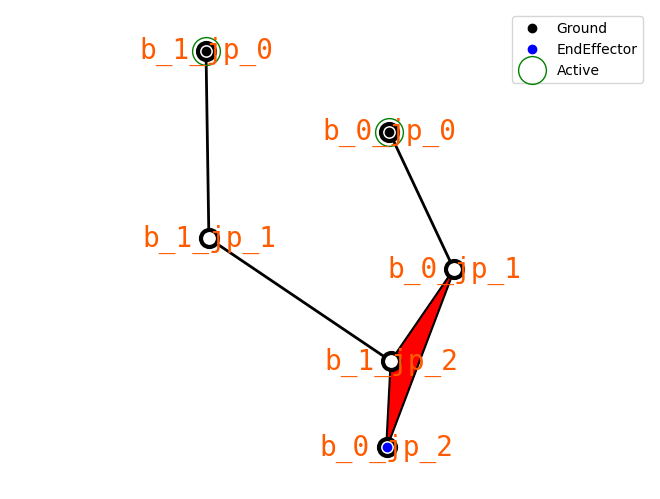

In [2]:
# first step - build branches.
# Main branch consists of two joints and end effector.
generator = Generator2DRotational()
joint = SchemeJoint(name="b_0_j_0", mutation_type=MutationType.ABSOLUTE, mutation_x=MutationCoordinate(
    freeze=0.0), mutation_y=MutationCoordinate(freeze=0.0), mutation_z=MutationCoordinate(freeze=0.0), active=True, attach_ground=True)
generator.add_joint(joint)
joint = SchemeJoint(name="b_0_j_1", mutation_type=MutationType.ABSOLUTE,
                    mutation_x=MutationCoordinate(mutation_origin=0.05, lower_bound=-0.1, upper_bound=0.1), mutation_y = MutationCoordinate(freeze=0.0), mutation_z=MutationCoordinate(mutation_origin=-0.2, lower_bound=-0.1, upper_bound=0.1))
generator.add_joint(joint)
ee = SchemeEE(name="b_0_j_2", mutation_x=MutationCoordinate(mutation_origin=0.0, lower_bound=-0.1, upper_bound=0.1), mutation_y=MutationCoordinate(freeze=0.0), mutation_z=MutationCoordinate(mutation_origin=-0.4, lower_bound=-0.1, upper_bound=0.1))
generator.add_joint(ee)
# Set the possible connections for the main branch, each connection is also a joint and it requires the description of possible mutations.
scheme_connection = SchemeConnectionJoint(name="G",
                                            mutation_type=MutationType.ABSOLUTE,
                                            mutation_x = MutationCoordinate(mutation_origin=-0.2, upper_bound=0.1, lower_bound=-0.1), 
                                            mutation_y = MutationCoordinate(freeze=0.0),
                                            mutation_z = MutationCoordinate(mutation_origin=0.0, lower_bound=0.0, upper_bound=0.2),
                                        active=False, attach_ground=True, connected_to=(0,-1))
connection = GeneratorConnection(scheme_connection, start_open=([1]), end_open=(), connected=None)
generator.add_connection(connection)
scheme_connection = SchemeConnectionJoint(name="CJ_0",
                                            mutation_type=MutationType.RELATIVE_PERCENTAGE,
                                            mutation_x = MutationCoordinate(mutation_origin=0, lower_bound=-0.2, upper_bound=0.2),
                                            mutation_y = MutationCoordinate(freeze=0.0),
                                            mutation_z = MutationCoordinate(mutation_origin=0.0, lower_bound=-0.4, upper_bound=0.4),
                                        active=False, attach_ground=False, connected_to=(0, 0))
connection = GeneratorConnection(scheme_connection, start_open=([1]), end_open=(), connected=None)
generator.add_connection(connection)
scheme_connection = SchemeConnectionJoint(name="CJ_1",
                                            mutation_type=MutationType.RELATIVE_PERCENTAGE, 
                                            mutation_x = MutationCoordinate(mutation_origin=0, lower_bound=-0.2, upper_bound=0.2),
                                            mutation_y = MutationCoordinate(freeze=0.0),
                                            mutation_z = MutationCoordinate(mutation_origin=0.0, lower_bound=-0.4, upper_bound=0.4),
                                        active=False, attach_ground=False, connected_to=(0, 1))
connection = GeneratorConnection(scheme_connection, start_open=(), end_open=([1]), connected=None)
generator.add_connection(connection)

# set the secondary branch - each branch has two connections in the start and end, here we have only one additional joint and the result is the two-link branch
generator.create_sub_branch()
joint = SchemeJoint(name="b_1_j_0", mutation_type=MutationType.RELATIVE, mutation_x=MutationCoordinate(mutation_origin=0.0, lower_bound=-0.1, upper_bound=0.1), mutation_y=MutationCoordinate(freeze=0.0), mutation_z=MutationCoordinate(mutation_origin=-0.2, lower_bound=-0.1, upper_bound=0.1))
generator.add_joint(joint, 1)

# build_all_topologies creates the list of possible graph schemes that can be constructed from the declared branches and connections.
generator.build_all_topologies()
print(len(generator.topologies))

for topology in generator.topologies:
    manager = MutableGraphManager(topology)
    manager.build_graph()
    manager.get_mutation_ranges()
    graph = manager.get_random_graph()
    manager.find_active_joints()
    patches = []
    for triangle in manager.triangle_links:
        patches.append([triangle,"#FF0000"])
    draw_joint_point(graph, patches_list=patches)
    plt.show()
    break

In [3]:
builder, crag, soft_constrain, reward_manager = inertial_config_two_link_six_trajectories()

In [4]:
for node in graph:
    print(node)

JointPoint(r=array([0., 0., 0.]), w=array([0, 1, 0]), active=True, attach_ground=True, attach_endeffector=False, name='b_0_jp_0', instance_counter=0)
JointPoint(r=array([ 0.15899383,  0.        , -0.33818798]), w=array([0, 1, 0]), active=False, attach_ground=False, attach_endeffector=False, name='b_0_jp_1', instance_counter=0)
JointPoint(r=array([-0.00652617,  0.        , -0.77495096]), w=array([0, 1, 0]), active=False, attach_ground=False, attach_endeffector=True, name='b_0_jp_2', instance_counter=0)
JointPoint(r=array([-0.45002142,  0.        ,  0.19918779]), w=array([0, 1, 0]), active=True, attach_ground=True, attach_endeffector=False, name='b_1_jp_0', instance_counter=0)
JointPoint(r=array([-0.44293245,  0.        , -0.26174433]), w=array([0, 1, 0]), active=False, attach_ground=False, attach_endeffector=False, name='b_1_jp_1', instance_counter=0)
JointPoint(r=array([ 0.00422318,  0.        , -0.56334393]), w=array([0, 1, 0]), active=False, attach_ground=False, attach_endeffector=Fa

In [5]:
from auto_robot_design.description.builder import jps_graph2pinocchio_robot, jps_graph2pinocchio_robot_3d_constraints

fixed_robot, free_robot = jps_graph2pinocchio_robot_3d_constraints(graph, builder)

In [6]:
pin.seed(1)
N_PROCESS = 1
population_size = 2
n_generations = 2

pool = multiprocessing.Pool(N_PROCESS)
runner = StarmapParallelization(pool.starmap)
    # create the problem for the current optimization
problem = MultiCriteriaProblem(manager, builder, reward_manager,
                                soft_constrain, elementwise_runner=runner, Actuator=builder.actuator['default'])

saver = ProblemSaver(problem, f"inertial_config_light\\filtered_topologies_50gen_64pop\\topology_{1}", True)
saver.save_nonmutable()
algorithm = AGEMOEA2(pop_size=population_size, save_history=True)
optimizer = PymooOptimizer(problem, algorithm, saver)

res = optimizer.run(
    True, **{
        "seed": 2,
        "termination": ("n_gen", n_generations),
        "verbose": True
    })

d:\Anaconda\envs\j_moves\lib\site-packages\pymoo\algorithms\moo\age2.py:101: RuntimeWarning: divide by zero encountered in scalar divide
  x = x - f / ff


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |        2 |      2 |             - |             -
     2 |        4 |      2 |  0.000000E+00 |             f


d:\Anaconda\envs\j_moves\lib\site-packages\pymoo\algorithms\moo\age2.py:101: RuntimeWarning: divide by zero encountered in scalar divide
  x = x - f / ff
